# MARCI/MDAD Dataset Exploration

This notebook performs descriptive analysis for the Martian dust storm segmentation dataset organized by Martian year (`MY28`, `MY31`, `MY32`).

It includes:

- **4.1 Dataset Overview:** number of images per Martian year.
- **4.2 Valid Data and No-Data Analysis:** valid and invalid pixel percentages.
- **4.3 Class Distribution Analysis:** storm, non-storm and no-data pixel percentages; RGB pairplot; 3D RGB scatter by class.
- **4.4 RGB Radiometric Analysis:** RGB intensity distributions, brightness estimation, storm vs non-storm comparisons, and visual examples of compact/diffuse storms.

Mask convention assumed by the notebook:

```text
0 = non-storm
1 = storm
2 = no-data / invalid
```

If a raw MDAD-style mask is found, the notebook also handles:

```text
0 = non-storm
1-250 = storm IDs
255 = no-data / invalid
```


## 0. Configuration

Edit this cell to choose which year and which images you want to analyze.

If `IMAGE_IDS_TO_ANALYZE` is empty, the notebook randomly selects `N_IMAGES_IF_EMPTY` images from `YEAR_TO_ANALYZE`.

All code assumes that this notebook is located at the same level as:

```text
MY28/
MY31/
MY32/
MARS/
Modelos generados/
```


In [80]:
from __future__ import annotations

from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple

import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from IPython.display import display

# Optional libraries.
try:
    import seaborn as sns
    HAS_SEABORN = True
except ImportError:
    HAS_SEABORN = False
    print("Seaborn is not installed. The 2D pairplot will be skipped.")

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    print("OpenCV is not installed. Compact/diffuse storm examples will use a simplified fallback.")

warnings.filterwarnings("ignore")

PROJECT_ROOT = Path.cwd()

YEARS = ["MY28", "MY31", "MY32"]

# Select one year and specific images for the detailed analysis.
YEAR_TO_ANALYZE = "MY32"

# Use image stems, for example:
# IMAGE_IDS_TO_ANALYZE = ["P08_day30", "P10_day12"]
# If empty, random images are selected.
IMAGE_IDS_TO_ANALYZE = ["D15_day04", "D16_day02", "F03_day14"]


N_IMAGES_IF_EMPTY = 3

# Single image used for RGB pairplot and 3D RGB scatter.
# If SINGLE_IMAGE_ID is None, the first selected image from the detailed analysis is used.
SINGLE_IMAGE_YEAR = YEAR_TO_ANALYZE
SINGLE_IMAGE_ID = None

# Random comparison section: five images per Martian year.
N_RANDOM_PER_YEAR = 5
RANDOM_SEED = 42

# Sampling limits to avoid excessive memory use.
MAX_PIXEL_SAMPLES_PER_CLASS = 3500
MAX_RADIOMETRIC_SAMPLES_PER_CLASS_PER_IMAGE = 2500

# Optional saving. By default, plots remain only in the notebook.
SAVE_FIGURES = False
OUTPUT_DIR = PROJECT_ROOT / "olga_data_exploration"

if SAVE_FIGURES:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Optional: mark almost-black RGB pixels as no-data.
# Keep False unless you are sure black borders are not already represented in the mask.
TREAT_BLACK_RGB_AS_NODATA = False
BLACK_RGB_THRESHOLD = 5

CLASS_NAMES = {
    0: "non-storm",
    1: "storm",
    2: "no-data"
}

CLASS_COLORS = {
    "non-storm": "#440154",
    "storm": "#2A9D9A",
    "no-data": "#FDE725"
}

plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 250

print(f"Project root: {PROJECT_ROOT}")


Project root: c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_sensing\Comparacion_de_metodos


## 1. Utility Functions

The following functions discover image-mask pairs, load RGB images and masks, normalize mask values, compute descriptive metrics, and generate visualizations.


In [81]:
def save_current_figure(name: str):
    """Save the current Matplotlib figure only when SAVE_FIGURES is enabled."""
    if SAVE_FIGURES:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        out_path = OUTPUT_DIR / name
        plt.savefig(out_path, bbox_inches="tight", dpi=250)
        print(f"Saved figure: {out_path}")


def normalize_key(text: Any) -> str:
    """Normalize names to match image and mask stems flexibly."""
    return (
        str(text)
        .lower()
        .replace("_mask_class", "")
        .replace("_multiclass", "")
        .replace("_mask", "")
        .replace("_class", "")
        .replace("_mdad", "")
        .replace("_", "")
        .replace("-", "")
        .replace(".", "")
        .replace(" ", "")
    )


def find_first_existing(candidates: List[Path]) -> Optional[Path]:
    """Return the first existing folder/path from a list."""
    for path in candidates:
        if path.exists():
            return path
    return None


def find_file_flexible(
    folders: List[Path],
    preferred_name: Optional[str] = None,
    tokens: Optional[List[str]] = None
) -> Optional[Path]:
    """Search for a file using exact filename first and flexible token matching second."""
    tokens = [normalize_key(t) for t in (tokens or []) if str(t) and str(t).lower() != "nan"]

    if preferred_name:
        for folder in folders:
            if not folder.exists():
                continue
            direct = folder / preferred_name
            if direct.exists():
                return direct
            matches = sorted(folder.rglob(preferred_name))
            if matches:
                return matches[0]

    all_files = []
    for folder in folders:
        if not folder.exists():
            continue
        for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
            all_files.extend(folder.rglob(ext))

    for token in tokens:
        for file in sorted(all_files):
            key = normalize_key(file.stem)
            if token and (token in key or key in token):
                return file

    return None


def repair_pair_paths(pair_df: pd.DataFrame, root: Path = PROJECT_ROOT) -> pd.DataFrame:
    """
    Repair image and mask paths from reports such as selected_top100.csv.
    This is useful when CSV paths refer to old folders like mdgm_rgb while the
    current folder uses selected_top100/images.
    """
    out = pair_df.copy()

    for idx, row in out.iterrows():
        year = str(row.get("year", ""))
        year_dir = root / year

        image_text = str(row.get("image_path", ""))
        mask_text = str(row.get("mask_path", row.get("mask_png_path", "")))

        image_path = Path(image_text)
        mask_path = Path(mask_text)

        if not image_path.is_absolute():
            image_path = root / image_path
        if not mask_path.is_absolute():
            mask_path = root / mask_path

        day_key = str(row.get("day_key", ""))
        image_stem = Path(image_text).stem
        mask_stem = Path(mask_text).stem

        image_folders = [
            year_dir / "selected_top100" / "images",
            year_dir / "images",
            year_dir / "mdgm_rgb",
        ]

        mask_folders = [
            year_dir / "selected_top100" / "masks",
            year_dir / "masks",
            year_dir / "masks_multiclass",
            year_dir / "masks_png_all",
        ]

        if not image_path.exists():
            fixed = find_file_flexible(
                image_folders,
                preferred_name=Path(image_text).name,
                tokens=[day_key, image_stem]
            )
            if fixed is not None:
                image_path = fixed

        if not mask_path.exists():
            fixed = find_file_flexible(
                mask_folders,
                preferred_name=Path(mask_text).name,
                tokens=[day_key, image_path.stem, image_stem, mask_stem]
            )
            if fixed is not None:
                mask_path = fixed

        out.at[idx, "image_path"] = str(image_path)
        out.at[idx, "mask_path"] = str(mask_path)

    missing_images = out[~out["image_path"].map(lambda x: Path(str(x)).exists())]
    missing_masks = out[~out["mask_path"].map(lambda x: Path(str(x)).exists())]

    if len(missing_images) > 0:
        raise FileNotFoundError(
            "Some image paths could not be repaired. Examples:\n"
            + "\n".join(missing_images["image_path"].head(10).astype(str).tolist())
        )

    if len(missing_masks) > 0:
        raise FileNotFoundError(
            "Some mask paths could not be repaired. Examples:\n"
            + "\n".join(missing_masks["mask_path"].head(10).astype(str).tolist())
        )

    return out


def load_year_records_from_report(year: str) -> Optional[pd.DataFrame]:
    """Load image-mask pairs from MYxx/reports/selected_top100.csv when available."""
    report_candidates = [
        PROJECT_ROOT / year / "reports" / "selected_top100.csv",
        PROJECT_ROOT / year / "selected_top100.csv",
    ]

    report_path = find_first_existing(report_candidates)

    if report_path is None:
        return None

    df = pd.read_csv(report_path)
    rows = []

    for i, row in df.iterrows():
        image_path = row.get("image_path", row.get("image", ""))
        mask_path = row.get("mask_png_path", row.get("mask_path", row.get("mask", "")))
        day_key = str(row.get("day_key", Path(str(image_path)).stem))
        idx_value = row.get("idx", row.get("source_index", row.get("rank", i)))

        try:
            idx_value = int(idx_value)
        except Exception:
            idx_value = i

        rows.append({
            "year": year,
            "idx": idx_value,
            "day_key": day_key,
            "image_id": f"{year}_{day_key}",
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "source_index": i,
            "source": "report",
        })

    if not rows:
        return None

    return repair_pair_paths(pd.DataFrame(rows), PROJECT_ROOT)


def load_year_records_from_folders(year: str) -> pd.DataFrame:
    """Match images and masks directly from folders when no report is available."""
    year_dir = PROJECT_ROOT / year

    image_folders = [
        year_dir / "selected_top100" / "images",
        year_dir / "images",
        year_dir / "mdgm_rgb",
    ]

    mask_folders = [
        year_dir / "selected_top100" / "masks",
        year_dir / "masks",
        year_dir / "masks_multiclass",
        year_dir / "masks_png_all",
    ]

    image_files = []
    for folder in image_folders:
        if folder.exists():
            for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
                image_files.extend(sorted(folder.glob(ext)))
            if image_files:
                break

    mask_files = []
    for folder in mask_folders:
        if folder.exists():
            for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
                mask_files.extend(sorted(folder.glob(ext)))
            if mask_files:
                break

    if not image_files:
        raise FileNotFoundError(f"No image files found for {year}.")
    if not mask_files:
        raise FileNotFoundError(f"No mask files found for {year}.")

    mask_by_key = {normalize_key(path.stem): path for path in mask_files}
    rows = []

    for i, image_path in enumerate(sorted(image_files)):
        image_key = normalize_key(image_path.stem)
        mask_path = mask_by_key.get(image_key)

        if mask_path is None:
            for mask_key, candidate_mask_path in mask_by_key.items():
                if image_key in mask_key or mask_key in image_key:
                    mask_path = candidate_mask_path
                    break

        if mask_path is None:
            continue

        rows.append({
            "year": year,
            "idx": i,
            "day_key": image_path.stem,
            "image_id": f"{year}_{image_path.stem}",
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "source_index": i,
            "source": "folder_match",
        })

    if not rows:
        raise RuntimeError(f"No valid image-mask matches were found for {year}.")

    return pd.DataFrame(rows)


def load_year_records(year: str) -> pd.DataFrame:
    """Load image-mask pairs for one Martian year using reports first, folders second."""
    report_df = load_year_records_from_report(year)

    if report_df is not None and len(report_df) > 0:
        return report_df.reset_index(drop=True)

    return load_year_records_from_folders(year).reset_index(drop=True)


def load_all_records(years: List[str] = YEARS) -> pd.DataFrame:
    """Load all image-mask pairs for the requested Martian years."""
    records = []

    for year in years:
        df = load_year_records(year)
        print(f"{year}: {len(df)} image-mask pairs")
        records.append(df)

    return pd.concat(records, ignore_index=True)


def normalize_mask(mask: np.ndarray) -> np.ndarray:
    """
    Normalize mask values to:
    0 = non-storm
    1 = storm
    2 = no-data
    """
    mask = mask.astype(np.uint16)

    unique_values = set(np.unique(mask).tolist())

    if unique_values.issubset({0, 1, 2}):
        return mask.astype(np.uint8)

    normalized = np.zeros(mask.shape, dtype=np.uint8)
    normalized[mask == 255] = 2
    normalized[(mask > 0) & (mask != 255)] = 1

    return normalized


def read_rgb(path: Path) -> np.ndarray:
    """Read an RGB image as uint8."""
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB"))


def read_mask(path: Path) -> np.ndarray:
    """Read and normalize a segmentation mask."""
    with Image.open(path) as img:
        mask = np.asarray(img.convert("L"))

    return normalize_mask(mask)


def load_image_and_mask(row: pd.Series) -> Tuple[np.ndarray, np.ndarray]:
    """Load RGB image and corresponding normalized mask."""
    rgb = read_rgb(Path(row["image_path"]))
    mask = read_mask(Path(row["mask_path"]))

    if rgb.shape[:2] != mask.shape:
        mask_img = Image.fromarray(mask.astype(np.uint8), mode="L")
        mask_img = mask_img.resize((rgb.shape[1], rgb.shape[0]), resample=Image.Resampling.NEAREST)
        mask = np.asarray(mask_img, dtype=np.uint8)

    if TREAT_BLACK_RGB_AS_NODATA:
        black_pixels = np.all(rgb <= BLACK_RGB_THRESHOLD, axis=2)
        mask = mask.copy()
        mask[black_pixels] = 2

    return rgb, mask


def choose_records(
    records: pd.DataFrame,
    year: str,
    image_ids: Optional[List[str]] = None,
    n_if_empty: int = 3,
    seed: int = RANDOM_SEED
) -> pd.DataFrame:
    """Select records by year and image ID. If image_ids is empty, randomly select images."""
    sub = records[records["year"] == year].copy().reset_index(drop=True)

    if sub.empty:
        raise ValueError(f"No records found for year: {year}")

    image_ids = image_ids or []

    if len(image_ids) > 0:
        requested_keys = [normalize_key(x) for x in image_ids]
        selected = sub[sub["day_key"].map(lambda x: normalize_key(x) in requested_keys)].copy()

        if selected.empty:
            raise ValueError(
                "No requested image IDs were found. Available examples:\n"
                + "\n".join(sub["day_key"].head(20).astype(str).tolist())
            )

        return selected.reset_index(drop=True)

    return sub.sample(
        n=min(n_if_empty, len(sub)),
        random_state=seed
    ).reset_index(drop=True)


def random_records_per_year(
    records: pd.DataFrame,
    n_per_year: int = 5,
    seed: int = RANDOM_SEED
) -> pd.DataFrame:
    """Randomly select n_per_year images for each Martian year."""
    selected = []

    for year in YEARS:
        sub = records[records["year"] == year].copy().reset_index(drop=True)

        if sub.empty:
            continue

        selected.append(
            sub.sample(n=min(n_per_year, len(sub)), random_state=seed).reset_index(drop=True)
        )

    return pd.concat(selected, ignore_index=True)


def compute_image_summary(row: pd.Series) -> Dict[str, Any]:
    """Compute valid/no-data and class distribution metrics for one image."""
    rgb, mask = load_image_and_mask(row)

    total_pixels = mask.size
    valid_pixels = int((mask != 2).sum())
    no_data_pixels = int((mask == 2).sum())
    storm_pixels = int((mask == 1).sum())
    non_storm_pixels = int((mask == 0).sum())

    valid_den = max(valid_pixels, 1)

    return {
        "year": row["year"],
        "day_key": row["day_key"],
        "height": int(mask.shape[0]),
        "width": int(mask.shape[1]),
        "total_pixels": int(total_pixels),
        "valid_pixels": valid_pixels,
        "no_data_pixels": no_data_pixels,
        "storm_pixels": storm_pixels,
        "non_storm_pixels": non_storm_pixels,
        "valid_pct_total": 100.0 * valid_pixels / total_pixels,
        "no_data_pct_total": 100.0 * no_data_pixels / total_pixels,
        "storm_pct_total": 100.0 * storm_pixels / total_pixels,
        "non_storm_pct_total": 100.0 * non_storm_pixels / total_pixels,
        "storm_pct_valid": 100.0 * storm_pixels / valid_den,
        "non_storm_pct_valid": 100.0 * non_storm_pixels / valid_den,
        "image_path": row["image_path"],
        "mask_path": row["mask_path"],
    }


def summarize_records(records: pd.DataFrame) -> pd.DataFrame:
    """Compute descriptive summaries for a dataframe of image-mask pairs."""
    rows = []

    for _, row in records.iterrows():
        rows.append(compute_image_summary(row))

    return pd.DataFrame(rows)


## 2. Load Image-Mask Pair Metadata

This section discovers the paired images and masks for all Martian years.


In [82]:
all_records = load_all_records(YEARS)

display(all_records[["year", "day_key", "image_path", "mask_path", "source"]].head(10))
print(f"Total paired images: {len(all_records)}")


MY28: 100 image-mask pairs
MY31: 100 image-mask pairs
MY32: 100 image-mask pairs


,year,day_key,image_path,mask_path,source
0,MY28,P09_day09,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
1,MY28,P09_day24,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
2,MY28,P09_day25,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
3,MY28,P04_day09,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
4,MY28,P09_day29,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
5,MY28,P09_day26,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
6,MY28,P09_day31,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
7,MY28,P08_day30,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
8,MY28,P03_day27,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report
9,MY28,P04_day10,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,report


Total paired images: 300


# 4.1 Dataset Overview

This section reports the number of available image-mask pairs per Martian year.


,year,n_images
0,MY28,100
1,MY31,100
2,MY32,100


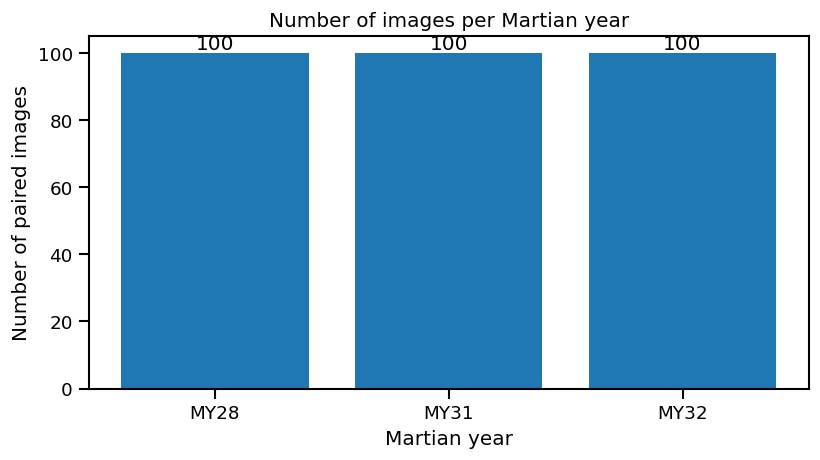

In [83]:
dataset_overview = (
    all_records
    .groupby("year")
    .size()
    .reset_index(name="n_images")
    .sort_values("year")
)

display(dataset_overview)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(dataset_overview["year"], dataset_overview["n_images"])
ax.set_title("Number of images per Martian year")
ax.set_xlabel("Martian year")
ax.set_ylabel("Number of paired images")
for idx, value in enumerate(dataset_overview["n_images"]):
    ax.text(idx, value, str(value), ha="center", va="bottom")
plt.tight_layout()
save_current_figure("dataset_overview_number_of_images.png")
plt.show()


# Section A — Detailed Analysis for a Selected Year and Selected Images

Edit the variables in **Section 0. Configuration**:

```python
YEAR_TO_ANALYZE = "MY28"
IMAGE_IDS_TO_ANALYZE = []
```

If `IMAGE_IDS_TO_ANALYZE` is empty, the notebook randomly selects `N_IMAGES_IF_EMPTY` images from the selected year.


In [84]:
selected_records = choose_records(
    records=all_records,
    year=YEAR_TO_ANALYZE,
    image_ids=IMAGE_IDS_TO_ANALYZE,
    n_if_empty=N_IMAGES_IF_EMPTY,
    seed=RANDOM_SEED
)

print(f"Selected year: {YEAR_TO_ANALYZE}")
display(selected_records[["year", "day_key", "image_path", "mask_path"]])


Selected year: MY32


,year,day_key,image_path,mask_path
0,MY32,D15_day04,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
1,MY32,F03_day14,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
2,MY32,D16_day02,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...


## 4.2 Valid Data and No-Data Analysis

For each selected image, this section computes the percentage of valid and no-data pixels.


,year,day_key,height,width,valid_pct_total,no_data_pct_total,valid_pixels,no_data_pixels
0,MY32,D15_day04,1801,3600,89.916,10.084,5829780,653820
1,MY32,F03_day14,1801,3600,80.902,19.098,5245390,1238210
2,MY32,D16_day02,1801,3600,84.641,15.359,5487777,995823


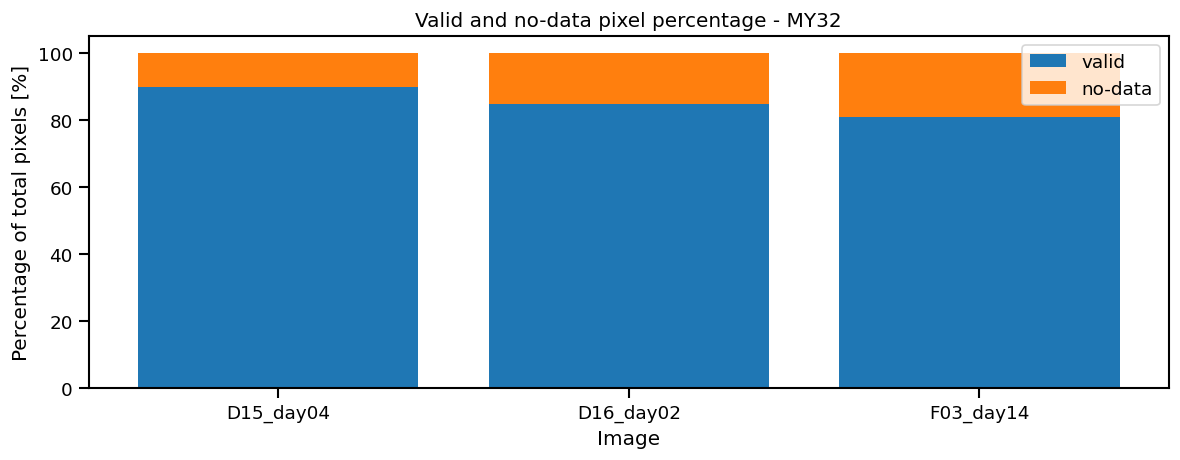

In [85]:
selected_summary = summarize_records(selected_records)

display(
    selected_summary[
        [
            "year", "day_key", "height", "width",
            "valid_pct_total", "no_data_pct_total",
            "valid_pixels", "no_data_pixels"
        ]
    ].round(3)
)

plot_df = selected_summary.sort_values("day_key")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(plot_df["day_key"], plot_df["valid_pct_total"], label="valid")
ax.bar(plot_df["day_key"], plot_df["no_data_pct_total"], bottom=plot_df["valid_pct_total"], label="no-data")
ax.set_title(f"Valid and no-data pixel percentage - {YEAR_TO_ANALYZE}")
ax.set_xlabel("Image")
ax.set_ylabel("Percentage of total pixels [%]")
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout()
save_current_figure(f"{YEAR_TO_ANALYZE}_valid_nodata_selected_images.png")
plt.show()


## 4.3 Class Distribution Analysis

This section computes the percentage of storm, non-storm and no-data pixels.


,year,day_key,storm_pct_total,non_storm_pct_total,no_data_pct_total,storm_pct_valid,non_storm_pct_valid
0,MY32,D15_day04,1.368,88.547,10.084,1.522,98.478
1,MY32,F03_day14,0.634,80.268,19.098,0.784,99.216
2,MY32,D16_day02,0.265,84.376,15.359,0.313,99.687


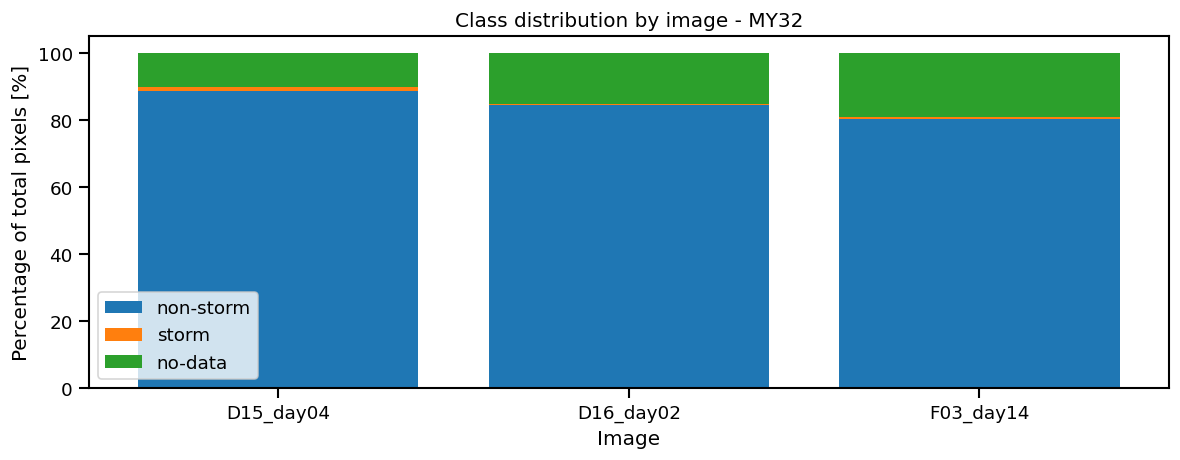

In [86]:
display(
    selected_summary[
        [
            "year", "day_key",
            "storm_pct_total", "non_storm_pct_total", "no_data_pct_total",
            "storm_pct_valid", "non_storm_pct_valid"
        ]
    ].round(3)
)

plot_df = selected_summary.sort_values("day_key")

fig, ax = plt.subplots(figsize=(10, 4))
bottom = np.zeros(len(plot_df))

for column, label in [
    ("non_storm_pct_total", "non-storm"),
    ("storm_pct_total", "storm"),
    ("no_data_pct_total", "no-data"),
]:
    ax.bar(plot_df["day_key"], plot_df[column], bottom=bottom, label=label)
    bottom += plot_df[column].to_numpy()

ax.set_title(f"Class distribution by image - {YEAR_TO_ANALYZE}")
ax.set_xlabel("Image")
ax.set_ylabel("Percentage of total pixels [%]")
ax.tick_params(axis="x", rotation=0)
ax.legend()
plt.tight_layout()
save_current_figure(f"{YEAR_TO_ANALYZE}_class_distribution_selected_images.png")
plt.show()


### 4.3.0 RGB and mask

Project root: C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_sensing\Comparacion_de_metodos
Images selected for visualization:
MY32 ['D15_day04', 'D16_day02', 'F03_day14']
MY32: 100 image-mask pairs loaded


,year,day_key,image_path,mask_path,source
0,MY32,D15_day04,C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,selected_top100_report
1,MY32,D16_day02,C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,selected_top100_report
2,MY32,F03_day14,C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,C:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,selected_top100_report


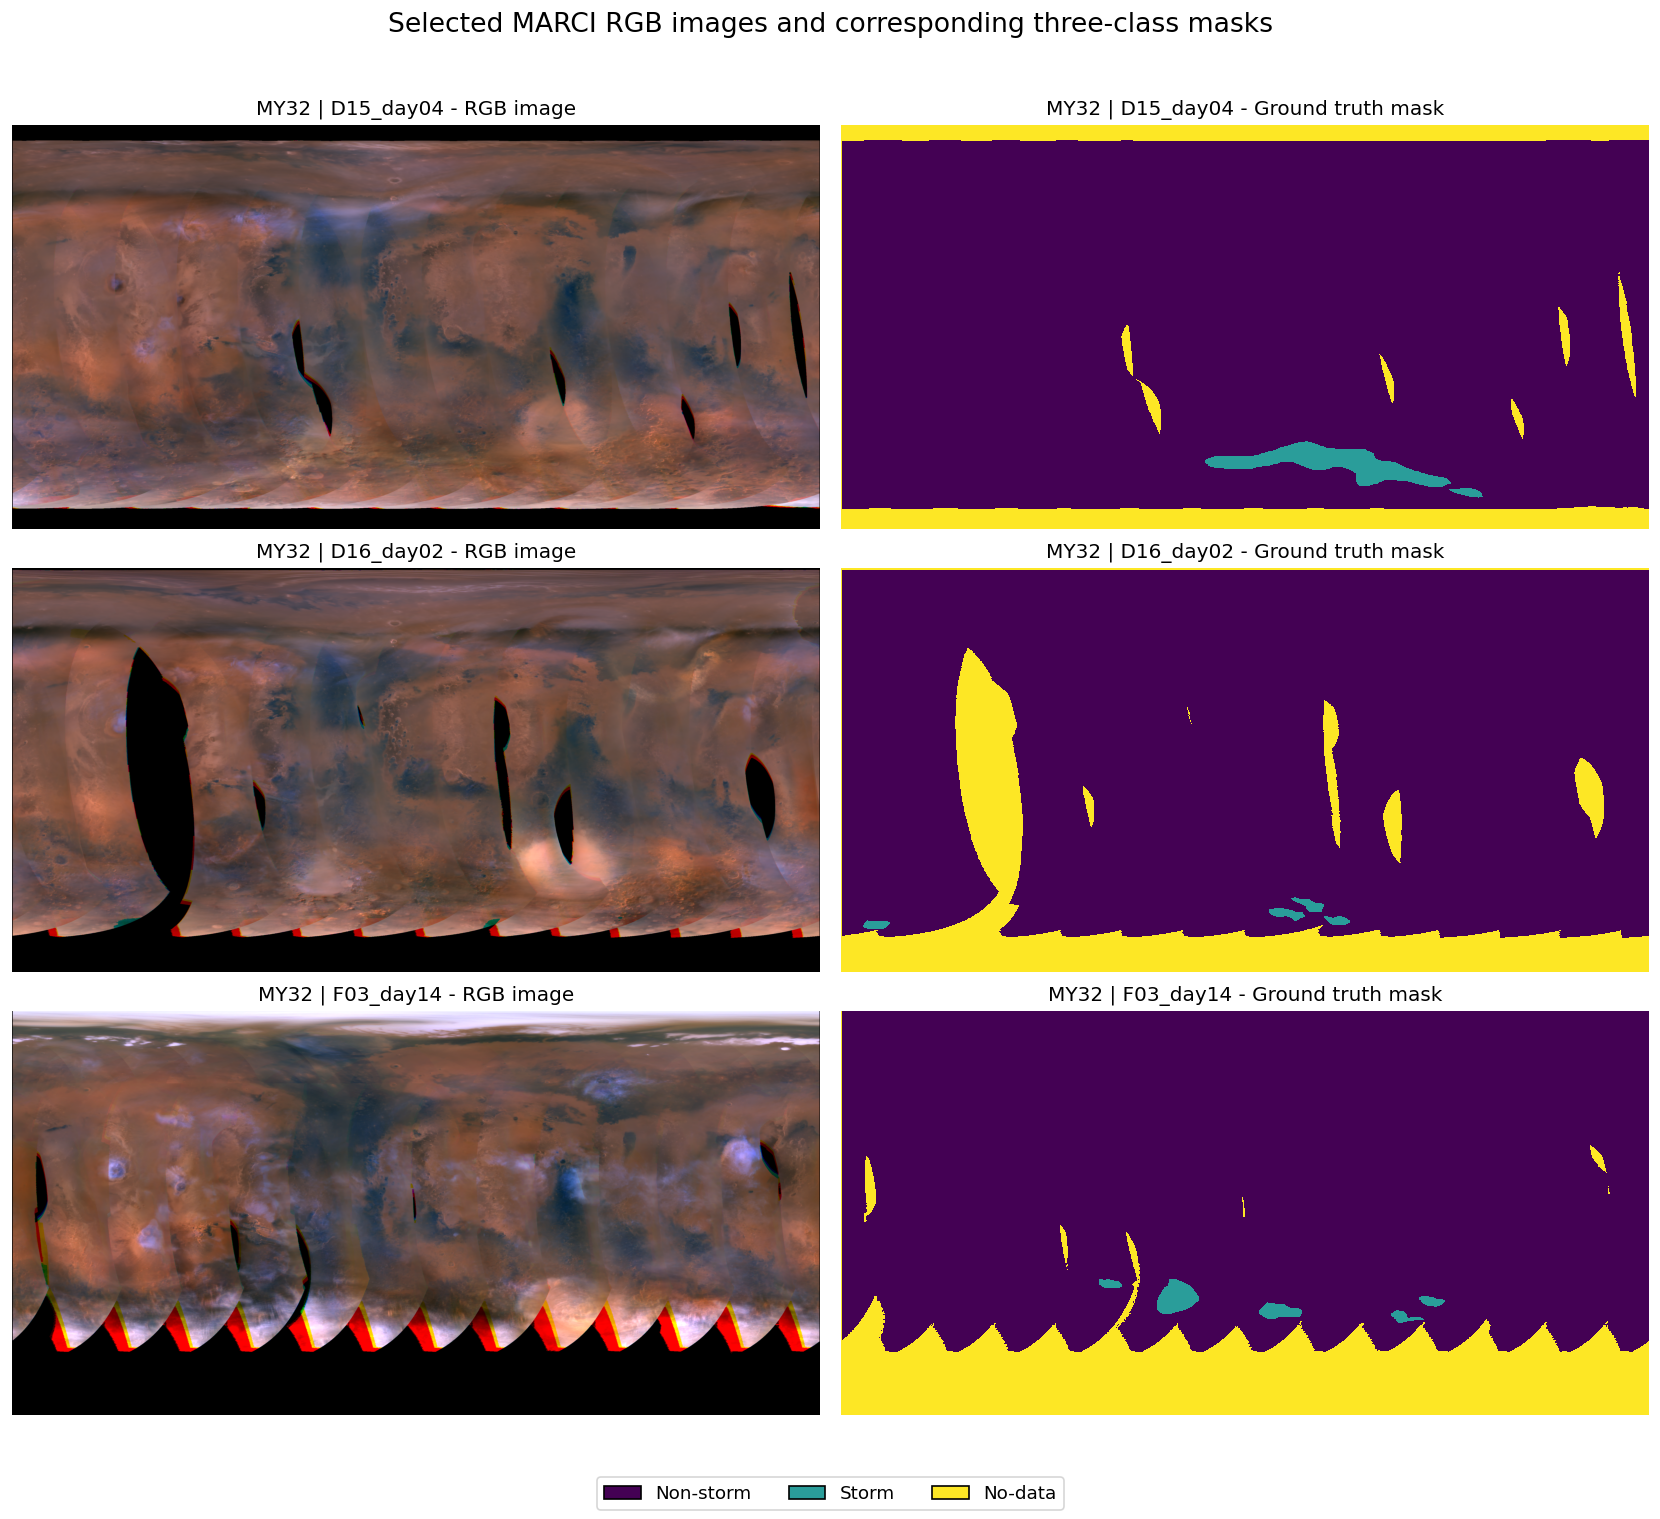

In [106]:
# ============================================================
# RGB image and multiclass mask visualization
# Same image-mask pairing logic used for training/exploration
# ============================================================

from pathlib import Path
from typing import Any, Optional, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from PIL import Image


# ------------------------------------------------------------
# 1. Project root detection
# ------------------------------------------------------------

def find_project_root(start_path: Path, years=("MY28", "MY31", "MY32")) -> Path:
    """
    Find the project root by looking for the MY folders.
    This allows the notebook to be executed either from the project root
    or from a subfolder.
    """
    start_path = start_path.resolve()

    for candidate in [start_path] + list(start_path.parents):
        if all((candidate / year).exists() for year in years):
            return candidate

    raise FileNotFoundError(
        "Project root was not found. Make sure the notebook is inside "
        "the project folder that contains MY28, MY31 and MY32."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
print(f"Project root: {PROJECT_ROOT}")


# ------------------------------------------------------------
# 2. Images listed in Block 0
# ------------------------------------------------------------
# This block tries to use the variables already defined in Block 0.
# If you want to force the selection manually, edit images_to_plot.

try:
    images_to_plot = {
        YEAR_TO_ANALYZE: IMAGE_IDS_TO_ANALYZE
    }

    if not IMAGE_IDS_TO_ANALYZE:
        raise ValueError("IMAGE_IDS_TO_ANALYZE is empty.")

except Exception:
    images_to_plot = {
        "MY28": ["P04_day09", "P08_day15", "P13_day27"],
        "MY31": ["D11_day28", "D02_day22", "D06_day12"],
        "MY32": ["D15_day04", "F03_day14", "D16_day02"],
    }

print("Images selected for visualization:")
for year, image_ids in images_to_plot.items():
    print(year, image_ids)


# ------------------------------------------------------------
# 3. Pairing helper functions
# ------------------------------------------------------------

def normalize_key(text: Any) -> str:
    """
    Normalize names to match image and mask stems flexibly.
    """
    return (
        str(text)
        .lower()
        .replace("_mask_class", "")
        .replace("_multiclass", "")
        .replace("_mask", "")
        .replace("_class", "")
        .replace("_mdad", "")
        .replace("_", "")
        .replace("-", "")
        .replace(".", "")
        .replace(" ", "")
    )


def find_first_existing(candidates: List[Path]) -> Optional[Path]:
    """
    Return the first existing path from a list.
    """
    for path in candidates:
        if path.exists():
            return path
    return None


def find_file_flexible(
    folders: List[Path],
    preferred_name: Optional[str] = None,
    tokens: Optional[List[str]] = None
) -> Optional[Path]:
    """
    Search a file using the same flexible logic used during dataset preparation.
    First, it checks exact filenames. Then, it tries token-based matching.
    """

    tokens = [
        normalize_key(t)
        for t in (tokens or [])
        if str(t) and str(t).lower() != "nan"
    ]

    # Exact filename search
    if preferred_name:
        for folder in folders:
            if not folder.exists():
                continue

            direct = folder / preferred_name
            if direct.exists():
                return direct

            matches = sorted(folder.rglob(preferred_name))
            if matches:
                return matches[0]

    # Flexible token search
    all_files = []
    for folder in folders:
        if not folder.exists():
            continue

        for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
            all_files.extend(folder.rglob(ext))

    for token in tokens:
        for file in sorted(all_files):
            key = normalize_key(file.stem)
            if token and (token in key or key in token):
                return file

    return None


def repair_pair_paths(pair_df: pd.DataFrame, root: Path = PROJECT_ROOT) -> pd.DataFrame:
    """
    Repair image and mask paths from reports such as selected_top100.csv.

    This is useful when the CSV contains old absolute or relative paths,
    but the current project stores the data in selected_top100/images
    and selected_top100/masks.
    """

    out = pair_df.copy()

    for idx, row in out.iterrows():
        year = str(row.get("year", ""))
        year_dir = root / year

        image_text = str(row.get("image_path", ""))
        mask_text = str(row.get("mask_path", row.get("mask_png_path", "")))

        image_path = Path(image_text)
        mask_path = Path(mask_text)

        if not image_path.is_absolute():
            image_path = root / image_path

        if not mask_path.is_absolute():
            mask_path = root / mask_path

        day_key = str(row.get("day_key", ""))
        image_stem = Path(image_text).stem
        mask_stem = Path(mask_text).stem

        image_folders = [
            year_dir / "selected_top100" / "images",
            year_dir / "images",
            year_dir / "mdgm_rgb",
        ]

        mask_folders = [
            year_dir / "selected_top100" / "masks",
            year_dir / "masks",
            year_dir / "masks_multiclass",
            year_dir / "masks_png_all",
        ]

        if not image_path.exists():
            fixed = find_file_flexible(
                folders=image_folders,
                preferred_name=Path(image_text).name,
                tokens=[day_key, image_stem]
            )
            if fixed is not None:
                image_path = fixed

        if not mask_path.exists():
            fixed = find_file_flexible(
                folders=mask_folders,
                preferred_name=Path(mask_text).name,
                tokens=[day_key, image_path.stem, image_stem, mask_stem]
            )
            if fixed is not None:
                mask_path = fixed

        out.at[idx, "image_path"] = str(image_path)
        out.at[idx, "mask_path"] = str(mask_path)

    missing_images = out[~out["image_path"].map(lambda x: Path(str(x)).exists())]
    missing_masks = out[~out["mask_path"].map(lambda x: Path(str(x)).exists())]

    if len(missing_images) > 0:
        raise FileNotFoundError(
            "Some image paths could not be repaired. Examples:\n"
            + "\n".join(missing_images["image_path"].head(10).astype(str).tolist())
        )

    if len(missing_masks) > 0:
        raise FileNotFoundError(
            "Some mask paths could not be repaired. Examples:\n"
            + "\n".join(missing_masks["mask_path"].head(10).astype(str).tolist())
        )

    return out


def load_year_records_from_report(year: str) -> Optional[pd.DataFrame]:
    """
    Load image-mask pairs from MYxx/reports/selected_top100.csv.
    This is the preferred pairing source.
    """

    report_candidates = [
        PROJECT_ROOT / year / "reports" / "selected_top100.csv",
        PROJECT_ROOT / year / "selected_top100.csv",
    ]

    report_path = find_first_existing(report_candidates)

    if report_path is None:
        return None

    df = pd.read_csv(report_path)
    rows = []

    for i, row in df.iterrows():
        image_path = row.get("image_path", row.get("image", ""))
        mask_path = row.get(
            "mask_png_path",
            row.get("mask_path", row.get("mask", ""))
        )

        day_key = str(row.get("day_key", Path(str(image_path)).stem))

        rows.append({
            "year": year,
            "idx": i,
            "day_key": day_key,
            "image_id": f"{year}_{day_key}",
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "source": "selected_top100_report",
        })

    if not rows:
        return None

    return repair_pair_paths(pd.DataFrame(rows), PROJECT_ROOT)


def load_year_records_from_folders(year: str) -> pd.DataFrame:
    """
    Fallback method: match images and masks directly from folders.
    """

    year_dir = PROJECT_ROOT / year

    image_folders = [
        year_dir / "selected_top100" / "images",
        year_dir / "images",
        year_dir / "mdgm_rgb",
    ]

    mask_folders = [
        year_dir / "selected_top100" / "masks",
        year_dir / "masks",
        year_dir / "masks_multiclass",
        year_dir / "masks_png_all",
    ]

    image_files = []
    for folder in image_folders:
        if folder.exists():
            for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
                image_files.extend(sorted(folder.glob(ext)))
            if image_files:
                break

    mask_files = []
    for folder in mask_folders:
        if folder.exists():
            for ext in ["*.png", "*.jpg", "*.jpeg", "*.tif", "*.tiff"]:
                mask_files.extend(sorted(folder.glob(ext)))
            if mask_files:
                break

    if not image_files:
        raise FileNotFoundError(f"No image files found for {year}.")

    if not mask_files:
        raise FileNotFoundError(f"No mask files found for {year}.")

    mask_by_key = {
        normalize_key(path.stem): path
        for path in mask_files
    }

    rows = []

    for i, image_path in enumerate(sorted(image_files)):
        image_key = normalize_key(image_path.stem)
        mask_path = mask_by_key.get(image_key)

        if mask_path is None:
            for mask_key, candidate_mask_path in mask_by_key.items():
                if image_key in mask_key or mask_key in image_key:
                    mask_path = candidate_mask_path
                    break

        if mask_path is None:
            continue

        rows.append({
            "year": year,
            "idx": i,
            "day_key": image_path.stem,
            "image_id": f"{year}_{image_path.stem}",
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "source": "folder_match",
        })

    if not rows:
        raise RuntimeError(f"No valid image-mask pairs were found for {year}.")

    return pd.DataFrame(rows)


def load_year_records(year: str) -> pd.DataFrame:
    """
    Load image-mask pairs for one Martian year.
    Reports are used first, folder matching is used only as fallback.
    """

    report_df = load_year_records_from_report(year)

    if report_df is not None and len(report_df) > 0:
        return report_df.reset_index(drop=True)

    return load_year_records_from_folders(year).reset_index(drop=True)


def load_all_records(years: List[str]) -> pd.DataFrame:
    """
    Load all image-mask pairs for the requested Martian years.
    """

    records = []

    for year in years:
        df = load_year_records(year)
        print(f"{year}: {len(df)} image-mask pairs loaded")
        records.append(df)

    return pd.concat(records, ignore_index=True)


# ------------------------------------------------------------
# 4. Load records and select only the images listed in Block 0
# ------------------------------------------------------------

years_to_load = list(images_to_plot.keys())
all_records_df = load_all_records(years_to_load)

selected_rows = []

for year, image_ids in images_to_plot.items():
    year_df = all_records_df[all_records_df["year"] == year].copy()

    for image_id in image_ids:
        target_key = normalize_key(image_id)

        matches = year_df[
            year_df["day_key"].map(normalize_key).eq(target_key)
            | year_df["image_path"].map(lambda x: target_key in normalize_key(Path(str(x)).stem))
            | year_df["mask_path"].map(lambda x: target_key in normalize_key(Path(str(x)).stem))
        ]

        if matches.empty:
            raise FileNotFoundError(
                f"No image-mask pair found for {year} | {image_id}"
            )

        selected_rows.append(matches.iloc[0])

selected_records_df = pd.DataFrame(selected_rows).reset_index(drop=True)

display(selected_records_df[["year", "day_key", "image_path", "mask_path", "source"]])


# ------------------------------------------------------------
# 5. Reading and mask normalization
# ------------------------------------------------------------

def read_rgb(path: Path) -> np.ndarray:
    """
    Read RGB image.
    """
    with Image.open(path) as img:
        return np.asarray(img.convert("RGB"))


def normalize_mask(mask: np.ndarray) -> np.ndarray:
    """
    Normalize mask values to:

    0 = non-storm
    1 = storm
    2 = no-data

    Supported cases:
    - already normalized masks with values {0, 1, 2}
    - raw MDAD-style masks where 255 = no-data and values > 0 = storm
    """

    if mask.ndim == 3:
        mask = mask[:, :, 0]

    mask = mask.astype(np.uint16)
    unique_values = set(np.unique(mask).tolist())

    if unique_values.issubset({0, 1, 2}):
        return mask.astype(np.uint8)

    normalized = np.zeros(mask.shape, dtype=np.uint8)
    normalized[(mask > 0) & (mask != 255)] = 1
    normalized[mask == 255] = 2

    return normalized


def read_mask(path: Path) -> np.ndarray:
    """
    Read and normalize segmentation mask.
    """
    with Image.open(path) as img:
        mask = np.asarray(img.convert("L"))

    return normalize_mask(mask)


# ------------------------------------------------------------
# 6. Mask colors
# ------------------------------------------------------------

mask_cmap = ListedColormap([
    "#440154",  # 0 = non-storm
    "#2A9D9A",  # 1 = storm
    "#FDE725",  # 2 = no-data
])

mask_norm = BoundaryNorm(
    boundaries=[-0.5, 0.5, 1.5, 2.5],
    ncolors=mask_cmap.N
)

legend_elements = [
    Patch(facecolor="#440154", edgecolor="k", label="Non-storm"),
    Patch(facecolor="#2A9D9A", edgecolor="k", label="Storm"),
    Patch(facecolor="#FDE725", edgecolor="k", label="No-data"),
]


# ------------------------------------------------------------
# 7. Plot RGB and mask side by side
# ------------------------------------------------------------

n_rows = len(selected_records_df)

fig, axes = plt.subplots(
    n_rows,
    2,
    figsize=(14, 4.2 * n_rows),
    squeeze=False
)

for i, row in selected_records_df.iterrows():
    year = row["year"]
    day_key = row["day_key"]

    rgb = read_rgb(Path(row["image_path"]))
    mask = read_mask(Path(row["mask_path"]))

    axes[i, 0].imshow(rgb)
    axes[i, 0].set_title(f"{year} | {day_key} - RGB image", fontsize=12)
    axes[i, 0].axis("off")

    axes[i, 1].imshow(
        mask,
        cmap=mask_cmap,
        norm=mask_norm,
        interpolation="nearest"
    )
    axes[i, 1].set_title(f"{year} | {day_key} - Ground truth mask", fontsize=12)
    axes[i, 1].axis("off")

fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=3,
    fontsize=11,
    frameon=True
)

fig.suptitle(
    "Selected MARCI RGB images and corresponding three-class masks",
    fontsize=16,
    y=0.995
)

plt.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()

### 4.3.1 RGB Pairplot by Class for One Image

This pairplot samples RGB pixels from one selected image and colors points by class.  
If `SINGLE_IMAGE_ID = None`, the first image in `selected_records` is used.


In [88]:
def select_single_image_record(
    records: pd.DataFrame,
    year: str,
    image_id: Optional[str],
    fallback_records: pd.DataFrame
) -> pd.Series:
    """Select one image for pairplot and 3D RGB visualization."""
    if image_id is None:
        return fallback_records.iloc[0]

    sub = records[records["year"] == year].copy()
    image_key = normalize_key(image_id)
    match = sub[sub["day_key"].map(lambda x: normalize_key(x) == image_key)]

    if match.empty:
        raise ValueError(f"Image ID not found for {year}: {image_id}")

    return match.iloc[0]


def sample_rgb_pixels_by_class(
    row: pd.Series,
    max_samples_per_class: int = MAX_PIXEL_SAMPLES_PER_CLASS,
    seed: int = RANDOM_SEED,
    include_no_data: bool = True
) -> pd.DataFrame:
    """Sample RGB pixels from one image and assign each sample to a class."""
    rng = np.random.default_rng(seed)
    rgb, mask = load_image_and_mask(row)
    rows = []
    class_values = [0, 1, 2] if include_no_data else [0, 1]

    for class_value in class_values:
        ys, xs = np.where(mask == class_value)

        if len(ys) == 0:
            continue

        n = min(max_samples_per_class, len(ys))
        chosen = rng.choice(len(ys), size=n, replace=False)
        pixels = rgb[ys[chosen], xs[chosen], :]

        rows.append(
            pd.DataFrame({
                "R": pixels[:, 0],
                "G": pixels[:, 1],
                "B": pixels[:, 2],
                "class": CLASS_NAMES[class_value],
                "year": row["year"],
                "day_key": row["day_key"],
            })
        )

    if len(rows) == 0:
        raise RuntimeError("No pixels were sampled.")

    return pd.concat(rows, ignore_index=True)


single_row = select_single_image_record(
    records=all_records,
    year=SINGLE_IMAGE_YEAR,
    image_id=SINGLE_IMAGE_ID,
    fallback_records=selected_records
)

print(f"Single image selected for RGB feature-space analysis: {single_row['year']} | {single_row['day_key']}")

rgb_sample_df = sample_rgb_pixels_by_class(single_row)

display(rgb_sample_df.groupby("class").size().reset_index(name="n_samples"))
display(rgb_sample_df.head())


Single image selected for RGB feature-space analysis: MY32 | D15_day04


,class,n_samples
0,no-data,3500
1,non-storm,3500
2,storm,3500


,R,G,B,class,year,day_key
0,96,75,72,non-storm,MY32,D15_day04
1,106,74,59,non-storm,MY32,D15_day04
2,111,80,74,non-storm,MY32,D15_day04
3,143,91,79,non-storm,MY32,D15_day04
4,93,71,68,non-storm,MY32,D15_day04


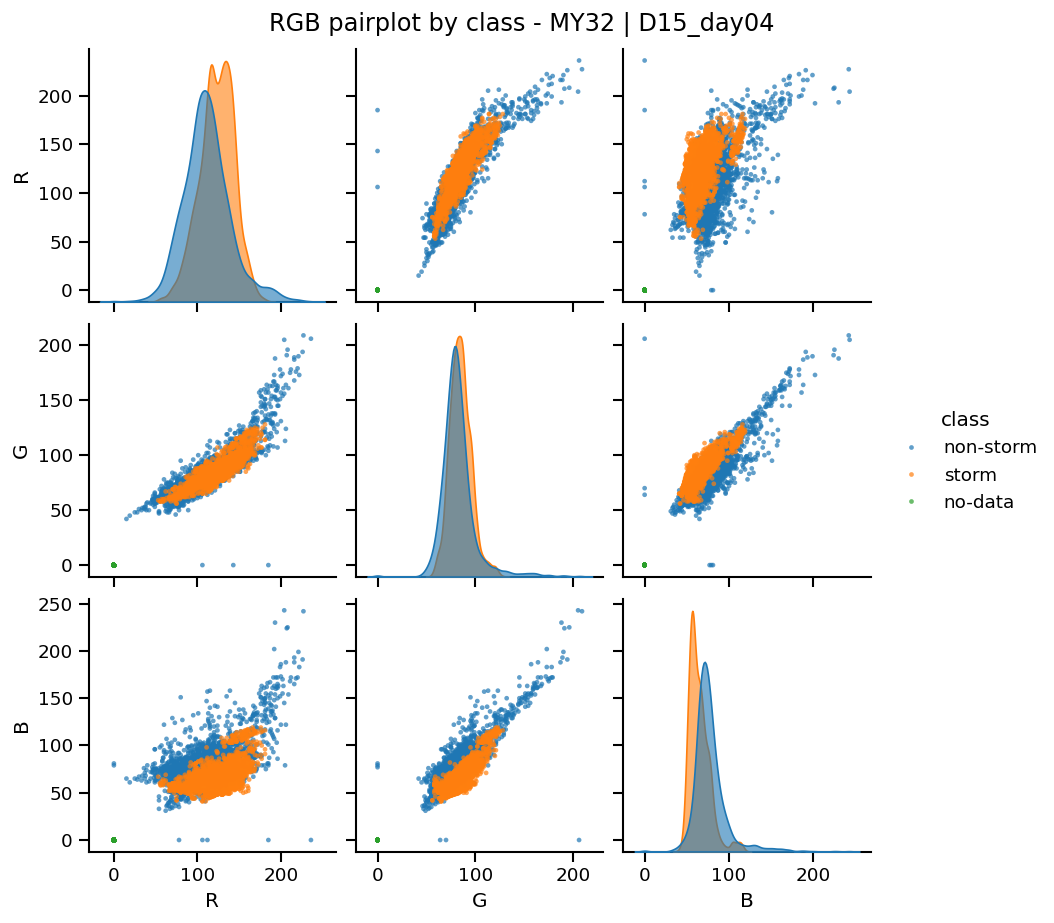

In [89]:
if HAS_SEABORN:
    sns.set_context("notebook")

    pair_grid = sns.pairplot(
        rgb_sample_df,
        vars=["R", "G", "B"],
        hue="class",
        corner=False,
        plot_kws={"s": 8, "alpha": 0.7, "linewidth": 0},
        diag_kws={"alpha": 0.6}
    )

    pair_grid.fig.suptitle(
        f"RGB pairplot by class - {single_row['year']} | {single_row['day_key']}",
        y=1.02
    )

    if SAVE_FIGURES:
        pair_grid.fig.savefig(
            OUTPUT_DIR / f"{single_row['year']}_{single_row['day_key']}_rgb_pairplot.png",
            bbox_inches="tight",
            dpi=250
        )

    plt.show()
else:
    print("Seaborn is not available. Install seaborn to generate the pairplot.")


### 4.3.2 3D RGB Scatter Plot by Class for One Image

A 3D pairplot is not the standard term; pairplots are normally a matrix of 2D plots.  
For RGB data, the equivalent 3D visualization is a scatter plot with:

- x-axis = R,
- y-axis = G,
- z-axis = B,
- color = class.


In [90]:
# try:
#     import plotly.express as px
#     import plotly.io as pio

#     HAS_PLOTLY = True
# except ImportError:
#     HAS_PLOTLY = False
#     print("Plotly is not installed. Install it with: pip install plotly")

# def plot_rgb_3d_scatter_plotly(rgb_sample_df: pd.DataFrame, title: str):
#     """
#     Plot RGB samples in interactive 3D feature space using Plotly.

#     Axes:
#     - x = R intensity
#     - y = G intensity
#     - z = B intensity

#     Points are colored according to the segmentation class.
#     """

#     if not HAS_PLOTLY:
#         print("Plotly is not available. Please install it with: pip install plotly")
#         return

#     fig = px.scatter_3d(
#         rgb_sample_df,
#         x="R",
#         y="G",
#         z="B",
#         color="class",
#         color_discrete_map=CLASS_COLORS,
#         opacity=0.45,
#         title=title,
#         hover_data={
#             "year": True,
#             "day_key": True,
#             "class": True,
#             "R": True,
#             "G": True,
#             "B": True,
#         }
#     )

#     fig.update_traces(
#         marker=dict(
#             size=3,
#             line=dict(width=0)
#         )
#     )

#     fig.update_layout(
#         width=900,
#         height=750,
#         scene=dict(
#             xaxis=dict(title="R Value", range=[0, 255]),
#             yaxis=dict(title="G Value", range=[0, 255]),
#             zaxis=dict(title="B Value", range=[0, 255]),
#         ),
#         legend_title_text="Class",
#         margin=dict(l=0, r=0, b=0, t=60)
#     )

#     fig.show()

#     # Optional: save as interactive HTML only if SAVE_FIGURES is enabled.
#     if SAVE_FIGURES:
#         OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
#         html_path = OUTPUT_DIR / f"{single_row['year']}_{single_row['day_key']}_rgb_3d_scatter_interactive.html"
#         fig.write_html(html_path)
#         print(f"Interactive 3D figure saved as: {html_path}")


# plot_rgb_3d_scatter_plotly(
#     rgb_sample_df,
#     title=f"Interactive 3D RGB scatter by class - {single_row['year']} | {single_row['day_key']}"
# )


In [91]:
# from pathlib import Path
# from io import BytesIO
# import numpy as np
# from PIL import Image
# import plotly.express as px
# import plotly.io as pio


# def create_plotly_rgb_rotation_gif(
#     rgb_sample_df: pd.DataFrame,
#     title: str,
#     output_dir: str = "olga_data_exploration",
#     gif_name: str = "GIF.gif",
#     n_frames: int = 72,
#     fps: int = 12,
#     radius: float = 2.3,
#     z_eye: float = 0.9,
#     width: int = 900,
#     height: int = 750,
#     scale: int = 2,
#     show_figure: bool = True,
# ):
#     """
#     Create an interactive Plotly 3D RGB scatter plot and save a rotating GIF.

#     The rotation is generated by moving the camera around the center of the
#     3D scatter plot, so the object appears to rotate around its own axis.

#     Parameters
#     ----------
#     rgb_sample_df : pd.DataFrame
#         DataFrame with columns: R, G, B, class, year, day_key.
#     title : str
#         Title of the figure.
#     output_dir : str
#         Folder where the GIF will be saved.
#     gif_name : str
#         Output GIF filename.
#     n_frames : int
#         Number of frames for a complete 360° rotation.
#     fps : int
#         Frames per second.
#     radius : float
#         Camera distance from the center.
#     z_eye : float
#         Camera height.
#     width, height : int
#         Figure size in pixels.
#     scale : int
#         Export scale factor for better quality.
#     show_figure : bool
#         If True, display the interactive Plotly figure.
#     """

#     output_dir = Path(output_dir).resolve()
#     output_dir.mkdir(parents=True, exist_ok=True)
#     gif_path = output_dir / gif_name

#     # ------------------------------------------------------------
#     # Build Plotly figure
#     # ------------------------------------------------------------
#     fig = px.scatter_3d(
#         rgb_sample_df,
#         x="R",
#         y="G",
#         z="B",
#         color="class",
#         color_discrete_map=CLASS_COLORS,
#         opacity=0.45,
#         title=title,
#         hover_data={
#             "year": True,
#             "day_key": True,
#             "class": True,
#             "R": True,
#             "G": True,
#             "B": True,
#         }
#     )

#     fig.update_traces(
#         marker=dict(
#             size=3,
#             line=dict(width=0)
#         )
#     )

#     fig.update_layout(
#         width=width,
#         height=height,
#         scene=dict(
#             xaxis=dict(title="R intensity", range=[0, 255]),
#             yaxis=dict(title="G intensity", range=[0, 255]),
#             zaxis=dict(title="B intensity", range=[0, 255]),
#             aspectmode="cube",
#             camera=dict(
#                 up=dict(x=0, y=0, z=1),
#                 center=dict(x=0, y=0, z=0),
#                 eye=dict(x=radius, y=0, z=z_eye),
#             )
#         ),
#         legend_title_text="Class",
#         margin=dict(l=0, r=0, b=0, t=60)
#     )

#     if show_figure:
#         fig.show()

#     # ------------------------------------------------------------
#     # Generate frames in memory
#     # ------------------------------------------------------------
#     frames = []
#     angles = np.linspace(0, 2 * np.pi, n_frames, endpoint=False)

#     for theta in angles:
#         x_eye = radius * np.cos(theta)
#         y_eye = radius * np.sin(theta)

#         fig.update_layout(
#             scene_camera=dict(
#                 up=dict(x=0, y=0, z=1),
#                 center=dict(x=0, y=0, z=0),
#                 eye=dict(x=x_eye, y=y_eye, z=z_eye)
#             )
#         )

#         img_bytes = pio.to_image(
#             fig,
#             format="png",
#             width=width,
#             height=height,
#             scale=scale
#         )

#         frame = Image.open(BytesIO(img_bytes)).convert("RGBA")
#         frames.append(frame)

#     # ------------------------------------------------------------
#     # Save GIF
#     # ------------------------------------------------------------
#     duration_ms = int(1000 / fps)

#     frames[0].save(
#         gif_path,
#         save_all=True,
#         append_images=frames[1:],
#         duration=duration_ms,
#         loop=0,
#         disposal=2
#     )

#     print(f"GIF saved successfully at:\n{gif_path}")
#     print(f"Exists: {gif_path.exists()}")

#     return fig, gif_path

# fig, gif_path = create_plotly_rgb_rotation_gif(
#     rgb_sample_df,
#     title=f"3D RGB scatter rotation - {single_row['year']} | {single_row['day_key']}",
#     gif_name="GIF.gif",
#     n_frames=72,
#     fps=12,
#     radius=2.3,
#     z_eye=0.9,
#     show_figure=True
# )

# gif_path

### 4.3.4 Correlation Matrix

## 4.4 RGB Radiometric Analysis

This section analyzes R, G and B intensity values, brightness, and RGB distributions in storm and non-storm regions.

Brightness is estimated as:

$Y = 0.2126R + 0.7152G + 0.0722B$


In [92]:
def sample_radiometric_pixels_for_records(
    records: pd.DataFrame,
    max_samples_per_class_per_image: int = MAX_RADIOMETRIC_SAMPLES_PER_CLASS_PER_IMAGE,
    seed: int = RANDOM_SEED
) -> pd.DataFrame:
    """Sample storm and non-storm RGB pixels from several images."""
    rng = np.random.default_rng(seed)
    frames = []

    for _, row in records.iterrows():
        rgb, mask = load_image_and_mask(row)

        for class_value in [0, 1]:
            ys, xs = np.where(mask == class_value)

            if len(ys) == 0:
                continue

            n = min(max_samples_per_class_per_image, len(ys))
            chosen = rng.choice(len(ys), size=n, replace=False)
            pixels = rgb[ys[chosen], xs[chosen], :].astype(np.float32)

            brightness = (
                0.2126 * pixels[:, 0]
                + 0.7152 * pixels[:, 1]
                + 0.0722 * pixels[:, 2]
            )

            frames.append(
                pd.DataFrame({
                    "year": row["year"],
                    "day_key": row["day_key"],
                    "class": CLASS_NAMES[class_value],
                    "R": pixels[:, 0],
                    "G": pixels[:, 1],
                    "B": pixels[:, 2],
                    "brightness": brightness,
                })
            )

    if len(frames) == 0:
        raise RuntimeError("No radiometric samples were generated.")

    return pd.concat(frames, ignore_index=True)


selected_radiometric_df = sample_radiometric_pixels_for_records(selected_records)

display(selected_radiometric_df.head())
display(selected_radiometric_df.groupby(["year", "day_key", "class"]).size().reset_index(name="n_samples"))


,year,day_key,class,R,G,B,brightness
0,MY32,D15_day04,non-storm,94.0,75.0,79.0,79.328201
1,MY32,D15_day04,non-storm,85.0,69.0,66.0,72.184998
2,MY32,D15_day04,non-storm,91.0,74.0,69.0,77.253204
3,MY32,D15_day04,non-storm,101.0,61.0,48.0,68.565399
4,MY32,D15_day04,non-storm,108.0,87.0,94.0,91.969994


,year,day_key,class,n_samples
0,MY32,D15_day04,non-storm,2500
1,MY32,D15_day04,storm,2500
2,MY32,D16_day02,non-storm,2500
3,MY32,D16_day02,storm,2500
4,MY32,F03_day14,non-storm,2500
5,MY32,F03_day14,storm,2500


In [93]:
radiometric_stats = (
    selected_radiometric_df
    .groupby(["year", "day_key", "class"])[["R", "G", "B", "brightness"]]
    .agg(["mean", "median", "std", "min", "max"])
    .reset_index()
)

display(radiometric_stats.round(3))


year    day_key      class           R                                 \
                                     mean median        std   min    max   
0  MY32  D15_day04  non-storm  110.428001  109.5  28.291000   0.0  246.0   
1  MY32  D15_day04      storm  123.204002  125.0  20.349001  53.0  192.0   
2  MY32  D16_day02  non-storm  110.725998  110.0  30.475000   0.0  255.0   
3  MY32  D16_day02      storm  137.199005  140.0  29.868999   0.0  202.0   
4  MY32  F03_day14  non-storm  118.222000  111.0  47.227001   0.0  255.0   
5  MY32  F03_day14      storm  122.591003  109.0  55.901001  39.0  255.0   

           G         ...          B                                 \
        mean median  ...       mean median        std   min    max   
0  81.635002   80.0  ...  76.598999   74.0  19.011000   0.0  212.0   
1  84.570000   84.0  ...  64.494003   62.0  12.344000  41.0  118.0   
2  81.188004   80.0  ...  74.994003   73.0  17.129000   0.0  160.0   
3  94.790001   93.0  ...  81.367996   79.0  20.896999   0.0  125.0   
4  87.125000   79.0  ...  82.309998   73.0  45.582001   0.0  255.0   
5  93.774002   84.0  ...  85.723999   74.0  44.082001   0.0  191.0   

   brightness                                                
         mean      median        std        min         max  
0   87.392998   85.322998  18.746000   5.343000  210.645996  
1   91.334000   90.994003  12.487000  57.941002  139.753998  
2   87.019997   85.460999  18.750999   4.910000  199.001999  
3  102.836998  102.583000  21.061001  39.118000  149.518997  
4   93.388000   85.611000  37.657001  13.606000  255.000000  
5   99.320000   89.060997  42.164001  27.851000  223.917007  

[6 rows x 23 columns]

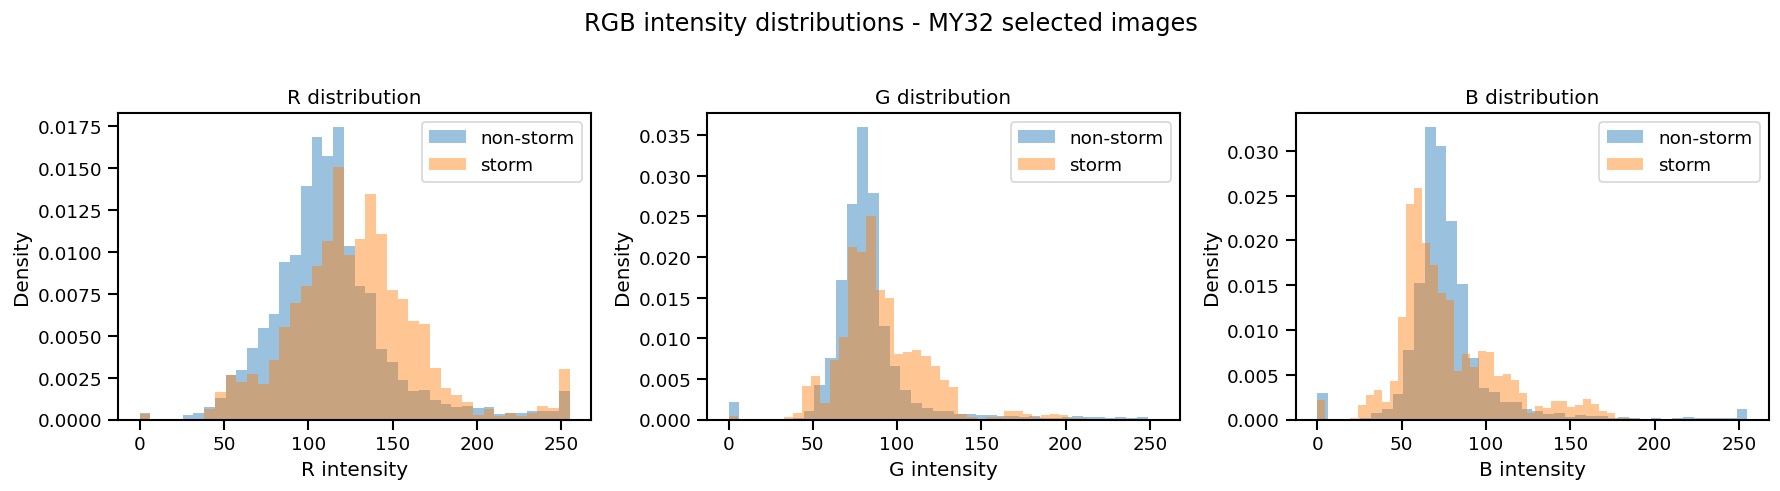

In [94]:
def plot_rgb_histograms_by_class(sample_df: pd.DataFrame, title_suffix: str):
    """Compare RGB distributions for storm and non-storm regions."""
    channels = ["R", "G", "B"]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, channel in zip(axes, channels):
        for class_name, group in sample_df.groupby("class"):
            ax.hist(
                group[channel],
                bins=40,
                alpha=0.45,
                density=True,
                label=class_name
            )

        ax.set_title(f"{channel} distribution")
        ax.set_xlabel(f"{channel} intensity")
        ax.set_ylabel("Density")
        ax.legend()

    fig.suptitle(f"RGB intensity distributions - {title_suffix}", y=1.02)
    plt.tight_layout()
    save_current_figure(f"rgb_histograms_{title_suffix.replace(' ', '_')}.png")
    plt.show()


plot_rgb_histograms_by_class(
    selected_radiometric_df,
    title_suffix=f"{YEAR_TO_ANALYZE} selected images"
)


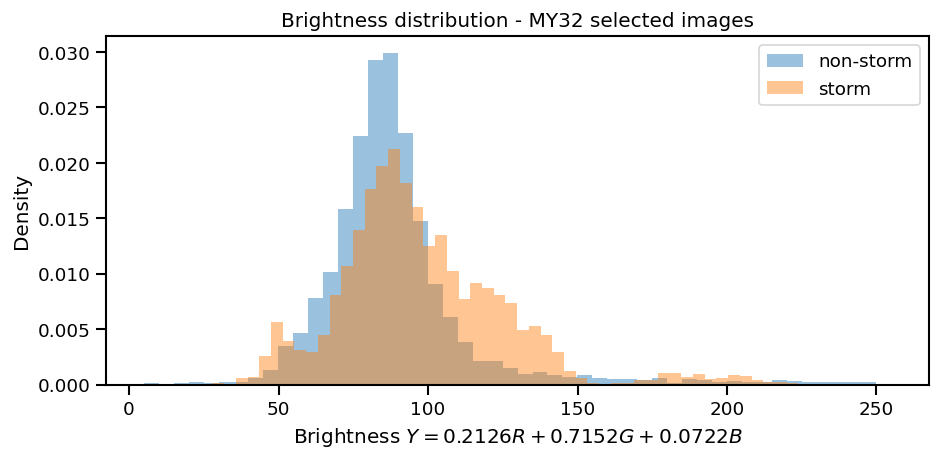

In [95]:
fig, ax = plt.subplots(figsize=(8, 4))

for class_name, group in selected_radiometric_df.groupby("class"):
    ax.hist(
        group["brightness"],
        bins=50,
        alpha=0.45,
        density=True,
        label=class_name
    )

ax.set_title(f"Brightness distribution - {YEAR_TO_ANALYZE} selected images")
ax.set_xlabel("Brightness $Y = 0.2126R + 0.7152G + 0.0722B$")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
save_current_figure(f"{YEAR_TO_ANALYZE}_brightness_distribution_selected_images.png")
plt.show()


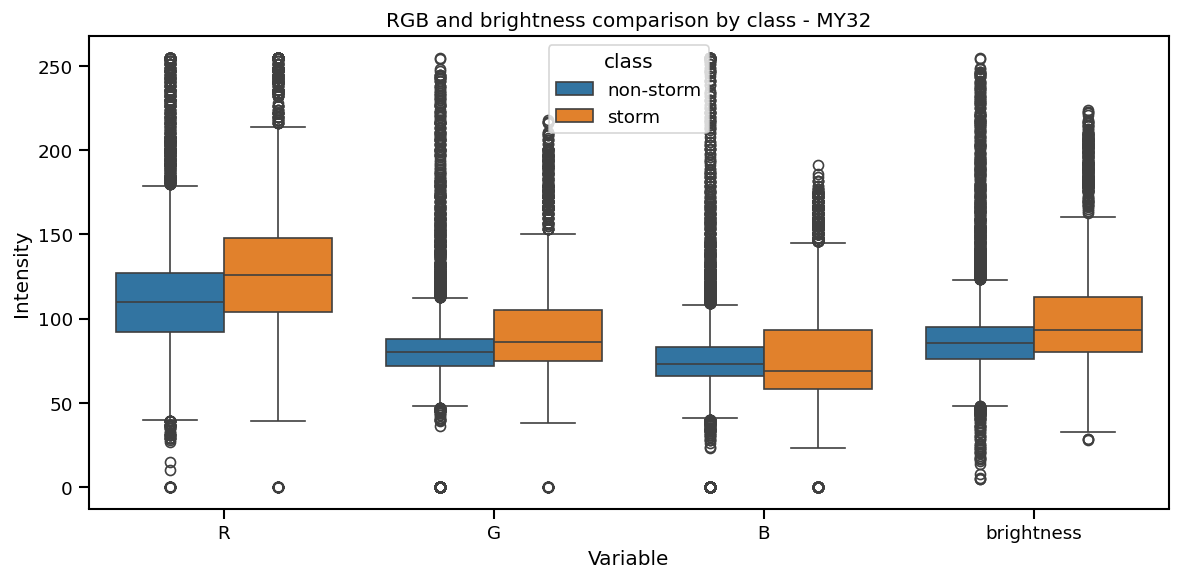

In [96]:
if HAS_SEABORN:
    plot_df = selected_radiometric_df.melt(
        id_vars=["year", "day_key", "class"],
        value_vars=["R", "G", "B", "brightness"],
        var_name="variable",
        value_name="value"
    )

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.boxplot(data=plot_df, x="variable", y="value", hue="class", ax=ax)
    ax.set_title(f"RGB and brightness comparison by class - {YEAR_TO_ANALYZE}")
    ax.set_xlabel("Variable")
    ax.set_ylabel("Intensity")
    plt.tight_layout()
    save_current_figure(f"{YEAR_TO_ANALYZE}_rgb_brightness_boxplot_selected_images.png")
    plt.show()
else:
    print("Seaborn is not available. Skipping boxplot.")


## 4.4.1 Visual Examples of Compact and Diffuse Storms

The following cell estimates simple morphology metrics from the storm mask and uses them to find possible compact and diffuse storm examples.

The classification is approximate and intended for visual exploration:

- **Compact storm candidate:** high dominance of the largest connected component.
- **Diffuse storm candidate:** lower dominance of the largest component or more fragmented storm regions.


In [97]:
def connected_component_metrics(mask: np.ndarray) -> Dict[str, float]:
    """Compute simple connected-component metrics for storm pixels."""
    storm = (mask == 1).astype(np.uint8)
    storm_pixels = int(storm.sum())

    if storm_pixels == 0:
        return {
            "n_components": 0,
            "largest_component_pixels": 0,
            "largest_component_ratio": 0.0,
            "storm_pixels": 0,
        }

    if HAS_CV2:
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(storm, connectivity=8)
        component_areas = stats[1:, cv2.CC_STAT_AREA] if num_labels > 1 else np.array([])
    else:
        component_areas = np.array([storm_pixels])

    if len(component_areas) == 0:
        return {
            "n_components": 0,
            "largest_component_pixels": 0,
            "largest_component_ratio": 0.0,
            "storm_pixels": storm_pixels,
        }

    largest = int(component_areas.max())

    return {
        "n_components": int(len(component_areas)),
        "largest_component_pixels": largest,
        "largest_component_ratio": float(largest / max(storm_pixels, 1)),
        "storm_pixels": storm_pixels,
    }


def storm_morphology_summary(records: pd.DataFrame) -> pd.DataFrame:
    """Compute compactness-related storm morphology metrics for each image."""
    rows = []

    for _, row in records.iterrows():
        _, mask = load_image_and_mask(row)
        valid = mask != 2
        storm_pct_valid = 100.0 * (mask == 1).sum() / max(valid.sum(), 1)

        metrics = connected_component_metrics(mask)

        rows.append({
            "year": row["year"],
            "day_key": row["day_key"],
            "storm_pct_valid": storm_pct_valid,
            **metrics,
            "image_path": row["image_path"],
            "mask_path": row["mask_path"],
        })

    return pd.DataFrame(rows)


morphology_df = storm_morphology_summary(all_records)

stormy_morphology_df = morphology_df[morphology_df["storm_pct_valid"] > 1.0].copy()

display(stormy_morphology_df.sort_values("storm_pct_valid", ascending=False).head(10))


,year,day_key,storm_pct_valid,n_components,largest_component_pixels,largest_component_ratio,storm_pixels,image_path,mask_path
0,MY28,P09_day09,16.204235,6,362849,0.416450,871291,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
100,MY31,D12_day12,14.753759,5,459907,0.548564,838384,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
1,MY28,P09_day24,14.385880,5,309638,0.395979,781956,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
200,MY32,F04_day22,12.536613,5,638462,0.917799,695645,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
201,MY32,F04_day21,12.498932,7,629728,0.918081,685918,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
101,MY31,D12_day08,11.750282,4,541240,0.811597,666883,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
2,MY28,P09_day25,11.570617,4,263316,0.418366,629391,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
3,MY28,P04_day09,10.188535,7,287738,0.484100,594377,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
102,MY31,D14_day18,9.700445,5,341573,0.605631,563995,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
4,MY28,P09_day29,9.493347,4,286963,0.555079,516977,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...


Compact storm candidate:


,year,day_key,storm_pct_valid,n_components,largest_component_pixels,largest_component_ratio,storm_pixels,image_path,mask_path
125,MY31,D06_day32,3.311043,1,190210,1.0,190210,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...


Diffuse storm candidate:


,year,day_key,storm_pct_valid,n_components,largest_component_pixels,largest_component_ratio,storm_pixels,image_path,mask_path
240,MY32,D17_day12,1.158471,6,13934,0.214911,64836,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...


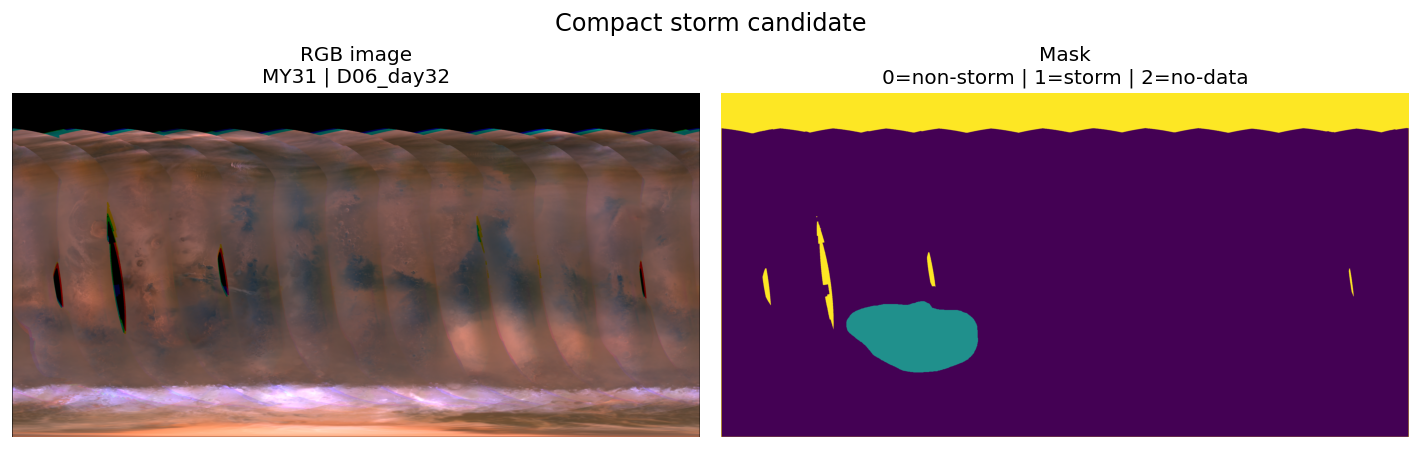

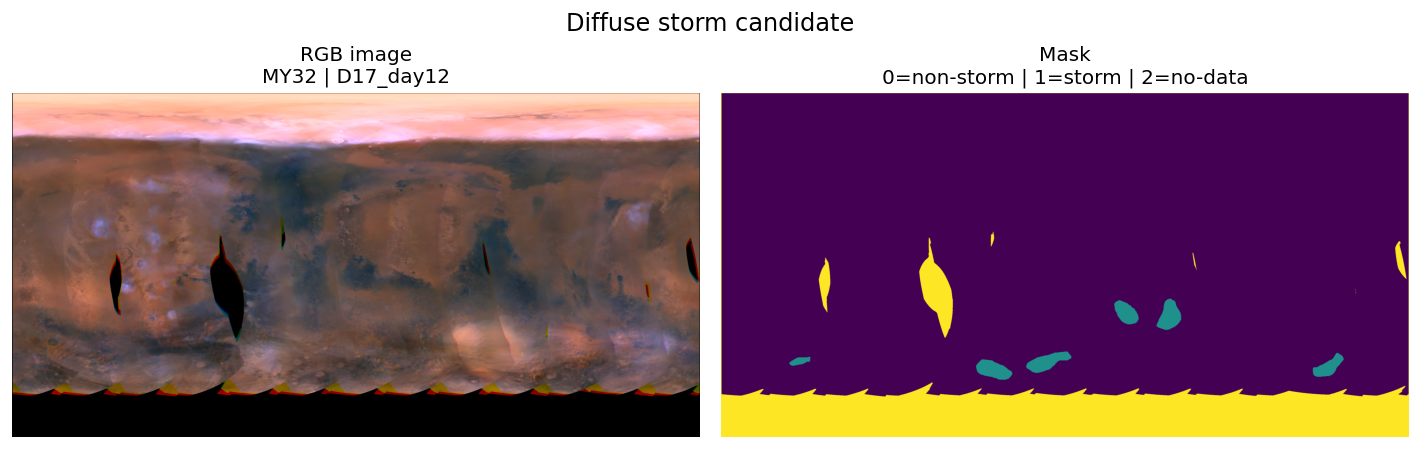

In [98]:
def plot_storm_example(row: pd.Series, title: str):
    """Plot RGB image and mask for a storm example."""
    rgb, mask = load_image_and_mask(row)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].imshow(rgb)
    axes[0].set_title(f"RGB image\n{row['year']} | {row['day_key']}")
    axes[0].axis("off")

    axes[1].imshow(mask, vmin=0, vmax=2)
    axes[1].set_title("Mask\n0=non-storm | 1=storm | 2=no-data")
    axes[1].axis("off")

    fig.suptitle(title)
    plt.tight_layout()
    save_current_figure(f"{title.replace(' ', '_').lower()}_{row['year']}_{row['day_key']}.png")
    plt.show()


if len(stormy_morphology_df) >= 2:
    compact_candidate = (
        stormy_morphology_df
        .sort_values(["largest_component_ratio", "storm_pct_valid"], ascending=[False, False])
        .iloc[0]
    )

    diffuse_candidate = (
        stormy_morphology_df
        .sort_values(["largest_component_ratio", "n_components"], ascending=[True, False])
        .iloc[0]
    )

    print("Compact storm candidate:")
    display(compact_candidate.to_frame().T)

    print("Diffuse storm candidate:")
    display(diffuse_candidate.to_frame().T)

    plot_storm_example(compact_candidate, "Compact storm candidate")
    plot_storm_example(diffuse_candidate, "Diffuse storm candidate")
else:
    print("Not enough stormy images were found to select compact and diffuse examples.")


# Section B — Random Five-Image Comparison Across Martian Years

This section randomly selects five images per Martian year and compares descriptive metrics across `MY28`, `MY31`, and `MY32`.

The random selection is controlled by:

```python
N_RANDOM_PER_YEAR = 5
RANDOM_SEED = 42
```


In [99]:
random_records = random_records_per_year(
    all_records,
    n_per_year=N_RANDOM_PER_YEAR,
    seed=RANDOM_SEED
)

display(random_records[["year", "day_key", "image_path", "mask_path"]])


,year,day_key,image_path,mask_path
0,MY28,P12_day23,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
1,MY28,P06_day08,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
2,MY28,P06_day19,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
3,MY28,P12_day30,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
4,MY28,P12_day17,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
5,MY31,G15_day21,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
6,MY31,G19_day32,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
7,MY31,D08_day27,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
8,MY31,G18_day28,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...
9,MY31,G16_day07,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...,c:\Users\olgaj\Desktop\2026_1_CODIGOS\Remote_s...


## B.1 Valid Data and No-Data Comparison Across Years


In [100]:
random_summary = summarize_records(random_records)

display(
    random_summary[
        [
            "year", "day_key",
            "valid_pct_total", "no_data_pct_total",
            "storm_pct_total", "non_storm_pct_total",
            "storm_pct_valid"
        ]
    ].round(3)
)

year_summary = (
    random_summary
    .groupby("year")[
        [
            "valid_pct_total",
            "no_data_pct_total",
            "storm_pct_total",
            "non_storm_pct_total",
            "storm_pct_valid"
        ]
    ]
    .agg(["mean", "std", "min", "max"])
)

display(year_summary.round(3))


,year,day_key,valid_pct_total,no_data_pct_total,storm_pct_total,non_storm_pct_total,storm_pct_valid
0,MY28,P12_day23,90.656,9.344,0.534,90.122,0.589
1,MY28,P06_day08,89.383,10.617,1.137,88.246,1.272
2,MY28,P06_day19,88.025,11.975,0.724,87.301,0.823
3,MY28,P12_day30,87.299,12.701,1.280,86.019,1.466
4,MY28,P12_day17,86.304,13.696,1.326,84.978,1.536
5,MY31,G15_day21,59.339,40.661,0.556,58.783,0.936
6,MY31,G19_day32,75.256,24.744,1.166,74.090,1.549
7,MY31,D08_day27,82.322,17.678,0.997,81.326,1.211
8,MY31,G18_day28,75.230,24.770,1.439,73.791,1.913
9,MY31,G16_day07,88.474,11.526,1.704,86.771,1.926


valid_pct_total                         no_data_pct_total          \
                mean     std     min     max              mean     std   
year                                                                     
MY28          88.333   1.716  86.304  90.656            11.667   1.716   
MY31          76.124  10.889  59.339  88.474            23.876  10.889   
MY32          74.965   9.032  65.719  86.036            25.035   9.032   

                     storm_pct_total                      non_storm_pct_total  \
         min     max            mean    std    min    max                mean   
year                                                                            
MY28   9.344  13.696           1.000  0.352  0.534  1.326              87.333   
MY31  11.526  40.661           1.172  0.437  0.556  1.704              74.952   
MY32  13.964  34.281           0.531  0.322  0.134  0.905              74.433   

                             storm_pct_valid                       
         std     min     max            mean    std    min    max  
year                                                               
MY28   1.993  84.978  90.122           1.137  0.414  0.589  1.536  
MY31  10.534  58.783  86.771           1.507  0.435  0.936  1.926  
MY32   8.984  65.452  85.131           0.710  0.403  0.162  1.052

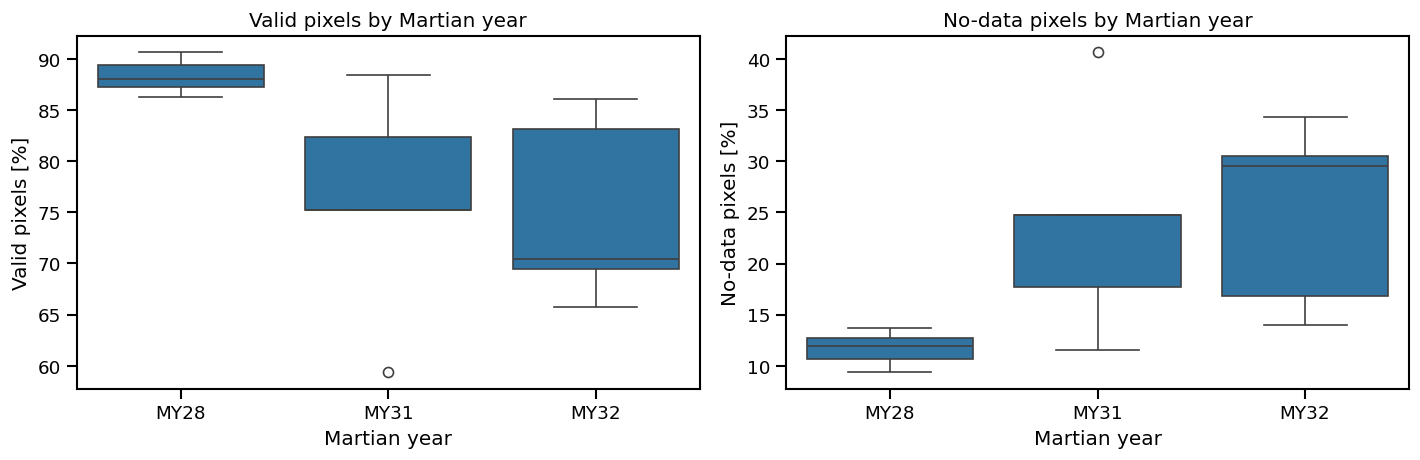

In [101]:
if HAS_SEABORN:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    sns.boxplot(data=random_summary, x="year", y="valid_pct_total", ax=axes[0])
    axes[0].set_title("Valid pixels by Martian year")
    axes[0].set_xlabel("Martian year")
    axes[0].set_ylabel("Valid pixels [%]")

    sns.boxplot(data=random_summary, x="year", y="no_data_pct_total", ax=axes[1])
    axes[1].set_title("No-data pixels by Martian year")
    axes[1].set_xlabel("Martian year")
    axes[1].set_ylabel("No-data pixels [%]")

    plt.tight_layout()
    save_current_figure("random_5_per_year_valid_nodata_boxplots.png")
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    random_summary.groupby("year")["valid_pct_total"].mean().plot(kind="bar", ax=ax)
    ax.set_title("Mean valid pixel percentage by Martian year")
    ax.set_ylabel("Valid pixels [%]")
    plt.tight_layout()
    plt.show()


## B.2 Class Distribution Comparison Across Years


,year,non_storm_pct_total,storm_pct_total,no_data_pct_total
0,MY28,87.333,1.000,11.667
1,MY31,74.952,1.172,23.876
2,MY32,74.433,0.531,25.035


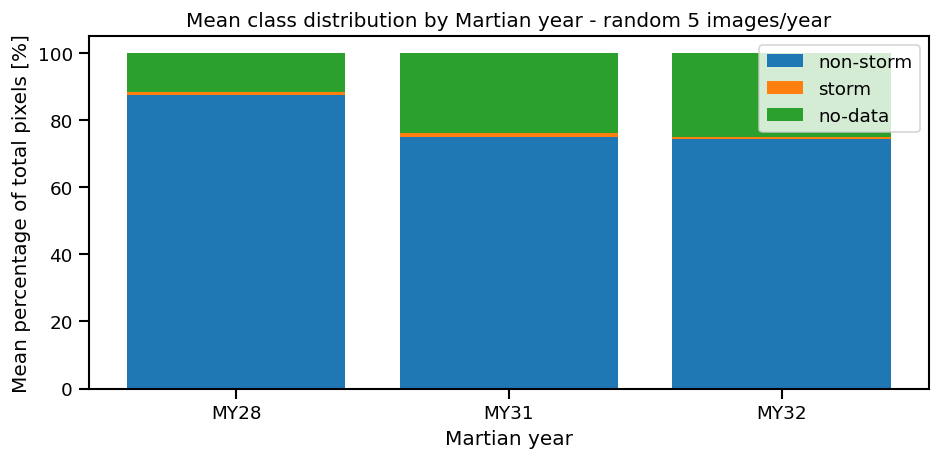

In [102]:
class_year_mean = (
    random_summary
    .groupby("year")[["non_storm_pct_total", "storm_pct_total", "no_data_pct_total"]]
    .mean()
    .reset_index()
)

display(class_year_mean.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
bottom = np.zeros(len(class_year_mean))

for column, label in [
    ("non_storm_pct_total", "non-storm"),
    ("storm_pct_total", "storm"),
    ("no_data_pct_total", "no-data"),
]:
    ax.bar(class_year_mean["year"], class_year_mean[column], bottom=bottom, label=label)
    bottom += class_year_mean[column].to_numpy()

ax.set_title("Mean class distribution by Martian year - random 5 images/year")
ax.set_xlabel("Martian year")
ax.set_ylabel("Mean percentage of total pixels [%]")
ax.legend()
plt.tight_layout()
save_current_figure("random_5_per_year_mean_class_distribution.png")
plt.show()


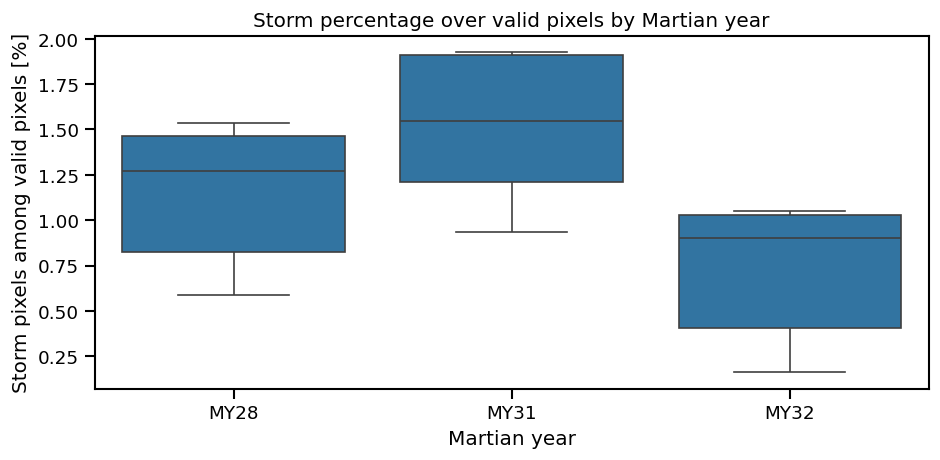

In [103]:
if HAS_SEABORN:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.boxplot(data=random_summary, x="year", y="storm_pct_valid", ax=ax)
    ax.set_title("Storm percentage over valid pixels by Martian year")
    ax.set_xlabel("Martian year")
    ax.set_ylabel("Storm pixels among valid pixels [%]")
    plt.tight_layout()
    save_current_figure("random_5_per_year_storm_pct_valid_boxplot.png")
    plt.show()
else:
    display(random_summary.groupby("year")["storm_pct_valid"].describe().round(3))


## B.3 RGB Radiometric Comparison Across Years

This section samples storm and non-storm pixels from the randomly selected images and compares RGB/brightness distributions across Martian years.


In [104]:
random_radiometric_df = sample_radiometric_pixels_for_records(random_records)

display(random_radiometric_df.head())

random_radiometric_stats = (
    random_radiometric_df
    .groupby(["year", "class"])[["R", "G", "B", "brightness"]]
    .agg(["mean", "median", "std"])
    .reset_index()
)

display(random_radiometric_stats.round(3))


,year,day_key,class,R,G,B,brightness
0,MY28,P12_day23,non-storm,122.0,83.0,73.0,90.569397
1,MY28,P12_day23,non-storm,115.0,83.0,78.0,89.442200
2,MY28,P12_day23,non-storm,88.0,75.0,76.0,77.835999
3,MY28,P12_day23,non-storm,113.0,75.0,67.0,82.501205
4,MY28,P12_day23,non-storm,114.0,79.0,71.0,85.863396


year      class           R                            G                    \
                          mean median        std       mean median        std   
0  MY28  non-storm  112.941002  110.0  34.112000  83.607002   80.0  22.476000   
1  MY28      storm  109.485001  109.0  17.573000  81.337997   79.0  10.869000   
2  MY31  non-storm  111.737000  110.0  33.087002  82.670998   80.0  23.292000   
3  MY31      storm  120.663002  119.0  30.025000  87.874001   84.0  20.809999   
4  MY32  non-storm  117.625000  110.0  50.272999  89.425003   80.0  38.094002   
5  MY32      storm  117.994003  115.0  33.080002  85.240997   81.0  25.128000   

           B                   brightness                        
        mean median        std       mean     median        std  
0  80.070999   74.0  30.999001  89.587997  85.727997  24.645000  
1  78.632004   73.0  22.490000  87.126999  85.570000  12.019000  
2  76.980003   74.0  25.746000  88.440002  85.718002  24.382000  
3  80.978996   74.0  26.938000  94.347000  90.857002  22.809999  
4  85.488998   74.0  43.458000  95.136002  85.874001  39.784000  
5  77.032997   71.0  33.808998  91.612000  87.081001  26.921000

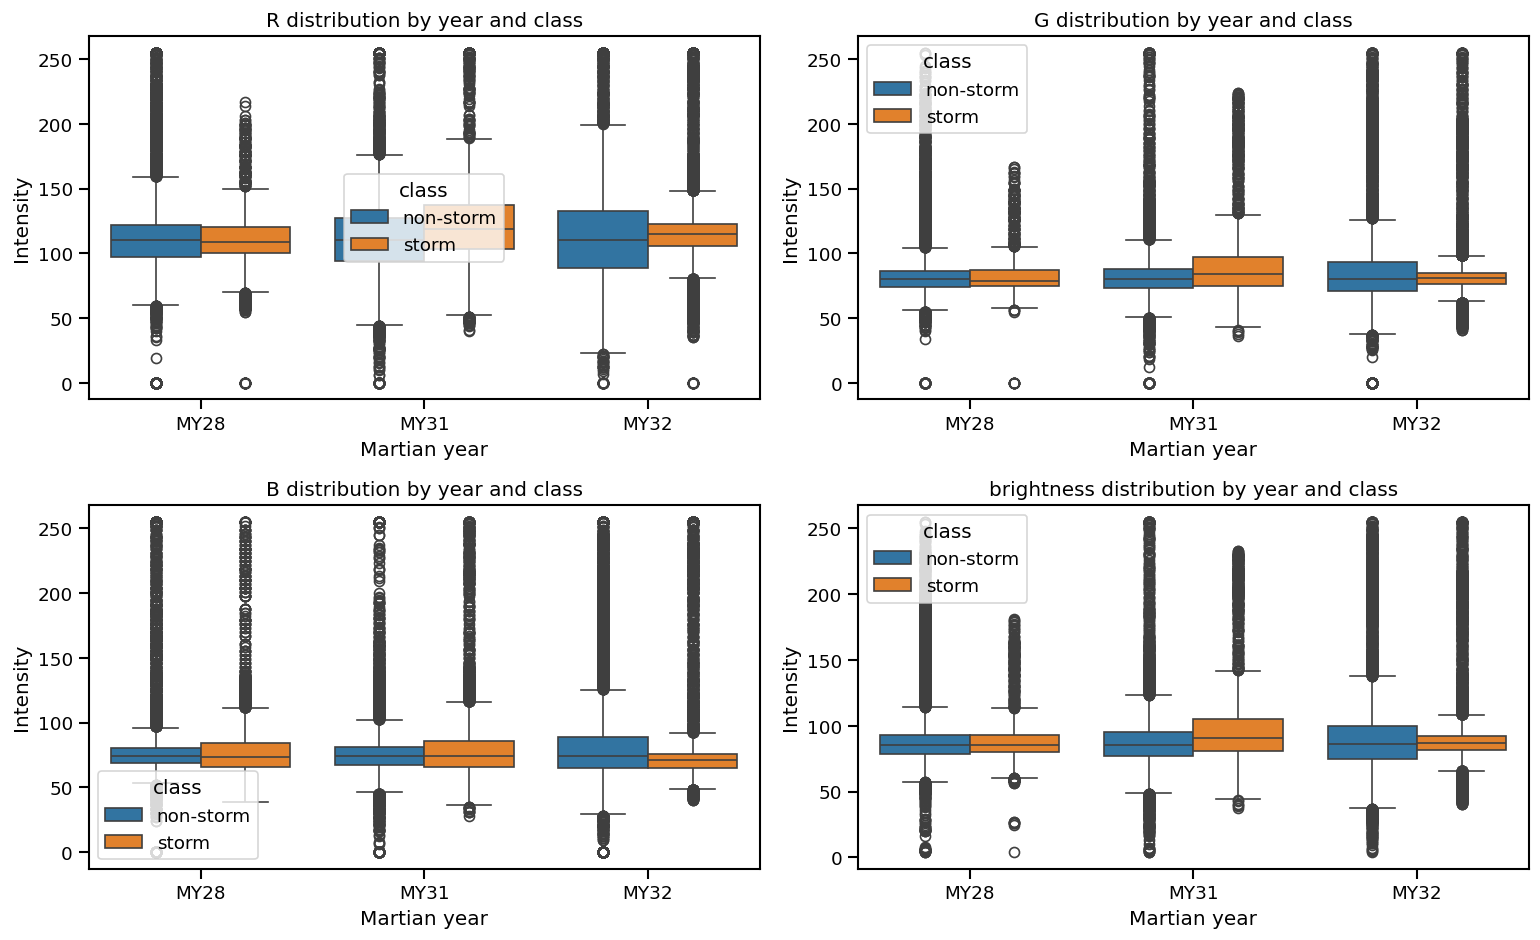

In [105]:
if HAS_SEABORN:
    fig, axes = plt.subplots(2, 2, figsize=(13, 8))
    axes = axes.ravel()

    for ax, variable in zip(axes, ["R", "G", "B", "brightness"]):
        sns.boxplot(
            data=random_radiometric_df,
            x="year",
            y=variable,
            hue="class",
            ax=ax
        )
        ax.set_title(f"{variable} distribution by year and class")
        ax.set_xlabel("Martian year")
        ax.set_ylabel("Intensity")

    plt.tight_layout()
    save_current_figure("random_5_per_year_rgb_brightness_boxplots.png")
    plt.show()
else:
    display(
        random_radiometric_df
        .groupby(["year", "class"])[["R", "G", "B", "brightness"]]
        .describe()
        .round(3)
    )


## B.4 Interpretation Aid

Use the tables and figures above to discuss:

1. whether the selected years have similar valid/no-data coverage,
2. whether the storm class is highly imbalanced,
3. whether storm pixels occupy a distinguishable region in RGB space,
4. whether storm and non-storm regions differ in brightness,
5. whether compact/diffuse storm morphologies are represented in the selected data.

Suggested wording for the report:

```text
The dataset shows a strong class imbalance, with non-storm pixels dominating most images. 
The no-data percentage varies across images and should be considered during model training and evaluation, since invalid pixels can bias both visual interpretation and metric computation if not masked out. 
RGB feature-space plots provide a first indication of how separable storm and non-storm pixels are using only color information. 
However, overlap between classes suggests that spatial context is necessary, supporting the use of convolutional segmentation models such as U-Net variants.
```
